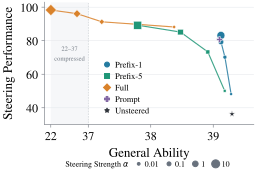

In [28]:
from pathlib import Path
from io import StringIO
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import SVG, display

DATA = [
    # series, strength, general ability, steering performance
    ("Prefix-1", 10,    39.123, 83.127),
    ("Prefix-1", 1,     39.124, 79.341),
    ("Prefix-1", 0.1,   39.187, 70.214),
    ("Prefix-1", 0.01,  39.286, 48.173),

    ("Prefix-5", 10,    37.791, 89.238),
    ("Prefix-5", 1,     38.476, 85.154),
    ("Prefix-5", 0.1,   38.914, 73.286),
    ("Prefix-5", 0.01,  39.183, 50.127),

    ("Full", 10,   22.042, 98.317),
    ("Full", 1,    32.487, 96.124),
    ("Full", 0.1,  37.216, 91.283),
    ("Full", 0.01, 38.374, 88.195),

    ("Prompt", None,    39.100, 80.733),
    ("Unsteered", None, 39.300, 36.271),
]

STYLES = {
    "Prefix-1": {"color": "#247BA0", "marker": "o"},
    "Prefix-5": {"color": "#209677", "marker": "s"},
    "Full": {"color": "#D9822B", "marker": "D"},
    "Prompt": {"color": "#8064A2", "marker": "P"},
    "Unsteered": {"color": "#30343B", "marker": "*"},
}
STRENGTH_SIZES = {0.01: 8, 0.1: 16, 1: 32, 10: 64}
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "notebooks").is_dir() and (p / "figs").is_dir())
OUTPUT = ROOT / "figs" / "steering_tradeoff_7b.pdf"

# Keep every score; compress only the displayed distance between 22 and 37.
COMPRESS_START, COMPRESS_END, COMPRESS_FACTOR = 22.0, 37.0, 0.04
COMPRESSED_END = COMPRESS_START + (COMPRESS_END - COMPRESS_START) * COMPRESS_FACTOR


def compress_x(values):
    values = np.asarray(values)
    return np.where(values < COMPRESS_START, values,
                    np.where(values <= COMPRESS_END,
                             COMPRESS_START + (values - COMPRESS_START) * COMPRESS_FACTOR,
                             COMPRESSED_END + values - COMPRESS_END))


def expand_x(values):
    values = np.asarray(values)
    return np.where(values < COMPRESS_START, values,
                    np.where(values <= COMPRESSED_END,
                             COMPRESS_START + (values - COMPRESS_START) / COMPRESS_FACTOR,
                             COMPRESS_END + values - COMPRESSED_END))


with plt.rc_context({"font.family": "STIXGeneral", "pdf.fonttype": 42,
                     "font.size": 12, "axes.labelsize": 13,
                     "axes.edgecolor": "#727780", "axes.linewidth": 0.6}):
    fig, ax = plt.subplots(figsize=(3.6, 2.5))
    fig.subplots_adjust(left=0.16, right=0.97, bottom=0.28, top=0.96)
    for name, style in STYLES.items():
        points = sorted((r for r in DATA if r[0] == name),
                        key=lambda r: r[1] or -1)
        x = [r[2] for r in points]
        y = [r[3] for r in points]
        if len(points) > 1:
            ax.plot(x, y, color=style["color"], linewidth=1.15, alpha=0.85, zorder=2)
        sizes = [STRENGTH_SIZES[r[1]] if r[1] is not None
                 else (48 if name == "Unsteered" else 32) for r in points]
        ax.scatter(x, y, s=sizes, **style, edgecolors="white", linewidths=0.5, zorder=3)

    ax.set_xscale("function", functions=(compress_x, expand_x))
    ax.set(xlim=(21.9, 39.65), ylim=(30, 103),
           xticks=[22, 37, 38, 39], yticks=[40, 60, 80, 100])
    ax.axvspan(22, 37, color="#64748B", alpha=0.055, linewidth=0, zorder=0)
    ax.axvline(37, color="#A4ABB3", linewidth=0.6, linestyle=":", zorder=1)
    ax.text(29.5, 72, "22–37\ncompressed", ha="center", va="center",
            fontsize=6.5, color="#737B84")
    ax.set_xlabel("General Ability", labelpad=4)
    ax.set_ylabel("Steering Performance", labelpad=5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(length=3, width=0.6, color="#727780")
    ax.grid(axis="y", color="#E4E7EB", linewidth=0.55)
    ax.set_axisbelow(True)
    handles = [Line2D([], [], color=s["color"], marker=s["marker"],
                      linestyle="None", markersize=5, label=name)
               for name, s in STYLES.items()]
    ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.25, 0.025),
              frameon=False, fontsize=8.5, handletextpad=0.45,
              handlelength=1.0, labelspacing=0.35, borderaxespad=0.3)
    strength_handles = [Line2D([], [], marker="o", color="#68717D", linestyle="None",
                               markersize=size ** 0.5, label=f"{strength:g}")
                        for strength, size in STRENGTH_SIZES.items()]
    strength_handles.insert(0, Line2D([], [], linestyle="None", label=r"Steering Strength $\alpha$"))
    fig.legend(handles=strength_handles,
               loc="lower center", bbox_to_anchor=(0.54, -0.005), ncol=5,
               frameon=False, fontsize=8, columnspacing=0.85,
               handletextpad=0.3, handlelength=0.9)
    fig.savefig(OUTPUT, format="pdf", bbox_inches="tight", pad_inches=0.03)
    preview = StringIO()
    fig.savefig(preview, format="svg", bbox_inches="tight", pad_inches=0.03)
    plt.close(fig)
    display(SVG(preview.getvalue()))

### Full steering: strength ratio versus error

Qwen3-4B, layer 18/head 0; 100 HarmBench examples. The curve compares full steering ($k=128$, distributed strength 0.1) with single-token steering at different multiples of $\beta$. Points show mean L2 error. The y-axis is zoomed to **0.131–0.138** and does not start at zero. Set `SHOW_STD = True` to show sample-standard-deviation bands with an expanded y-axis. The five measured mean/std pairs are embedded directly in `DATA`; plotting does not read an external results file.

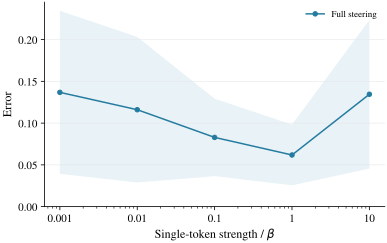

In [38]:
from pathlib import Path
from io import StringIO
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import SVG, display

DATA = [
    # series, strength / beta, error mean, error std (100 examples)
    ("Full", 0.001, 0.13683024963364004, 0.09757453145560606),
    ("Full", 0.01, 0.11603124692104757, 0.08716405449501407),
    ("Full", 0.1, 0.08288122325669974, 0.0463953296672038),
    ("Full", 1.0, 0.0618255411228165, 0.036354551554968),
    ("Full", 10.0, 0.1345523192640394, 0.08897744220567634),
]

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "notebooks").is_dir() and (p / "figs").is_dir())
lengths = [128]
factors = np.array([0.001, 0.01, 0.1, 1.0, 10.0])
SHOW_STD = True  # Set True to show mean +/- sample standard deviation.
colors = ["#247BA0"]
markers = ["o"]

with plt.rc_context({"font.family": "STIXGeneral", "pdf.fonttype": 42,
                     "font.size": 11, "axes.labelsize": 12}):
    fig, ax = plt.subplots(figsize=(5.4, 3.4), constrained_layout=True)
    for k, color, marker in zip(lengths, colors, markers):
        rows = sorted((r for r in DATA if r[0] == "Full"), key=lambda r: r[1])
        factors = np.array([r[1] for r in rows])
        means = np.array([r[2] for r in rows])
        stds = np.array([r[3] for r in rows])
        label = "Full steering"
        ax.plot(factors, means, marker=marker, color=color, linewidth=1.5,
                markersize=4.5, label=label)
        if SHOW_STD:
            ax.fill_between(factors, means - stds, means + stds,
                            color=color, alpha=0.10, linewidth=0)
    ax.set_xscale("log")
    ax.set_xticks(factors, ["0.001", "0.01", "0.1", "1", "10"])
    ax.set_xlabel(r"Single-token strength / $\beta$")
    ax.set_ylabel("Error")
    if SHOW_STD:
        ax.set_ylim(bottom=0)
    else:
        ax.set_ylim(0.131, 0.138)
        ax.set_yticks(np.arange(0.131, 0.1381, 0.001))
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#E4E7EB", linewidth=0.6)
    ax.legend(frameon=False, fontsize=9, loc="upper right")
    output_path = ROOT / "figs/lemma5_qwen3_full_strength_ratio.pdf"
    fig.savefig(output_path, format="pdf", bbox_inches="tight", pad_inches=0.03)
    preview = StringIO()
    fig.savefig(preview, format="svg", bbox_inches="tight", pad_inches=0.03)
    display(SVG(preview.getvalue()))
    plt.close(fig)


### Combined Figure 4

Left: original OLMo 3 7B safety–capability trade-off. Right: Qwen3-4B layer 18/head 0 strength-matching error over 100 HarmBench examples (mean ± sample standard deviation). This standalone cell exports the combined PDF to the project and manuscript figure directories.

Saved /home/xzascc/Documents/code/Prefix/figs/steering_tradeoff_7b_combined.pdf
Saved /home/xzascc/Documents/code/Prefix/6aa4d604d1c9e8e9c1117855/figs/steering_tradeoff_7b_combined.pdf


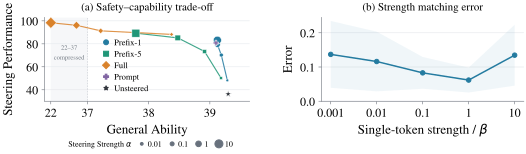

In [1]:
# Combined Figure 4: original trade-off on the left, strength-ratio error on the right.
# Self-contained: rerun this cell directly without rerunning the earlier plots.
from pathlib import Path
from io import StringIO
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import SVG, display

DATA = [
    # series, strength, general ability, steering performance
    ("Prefix-1", 10,    39.123, 83.127),
    ("Prefix-1", 1,     39.124, 79.341),
    ("Prefix-1", 0.1,   39.187, 70.214),
    ("Prefix-1", 0.01,  39.286, 48.173),

    ("Prefix-5", 10,    37.791, 89.238),
    ("Prefix-5", 1,     38.476, 85.154),
    ("Prefix-5", 0.1,   38.914, 73.286),
    ("Prefix-5", 0.01,  39.183, 50.127),

    ("Full", 10,   22.042, 98.317),
    ("Full", 1,    32.487, 96.124),
    ("Full", 0.1,  37.216, 91.283),
    ("Full", 0.01, 38.374, 88.195),

    ("Prompt", None,    39.100, 80.733),
    ("Unsteered", None, 39.300, 36.271),
]

STYLES = {
    "Prefix-1": {"color": "#247BA0", "marker": "o"},
    "Prefix-5": {"color": "#209677", "marker": "s"},
    "Full": {"color": "#D9822B", "marker": "D"},
    "Prompt": {"color": "#8064A2", "marker": "P"},
    "Unsteered": {"color": "#30343B", "marker": "*"},
}
STRENGTH_SIZES = {0.01: 8, 0.1: 16, 1: 32, 10: 64}
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "notebooks").is_dir() and (p / "figs").is_dir())
# Export paths are set after drawing both panels.

# Keep every score; compress only the displayed distance between 22 and 37.
COMPRESS_START, COMPRESS_END, COMPRESS_FACTOR = 22.0, 37.0, 0.04
COMPRESSED_END = COMPRESS_START + (COMPRESS_END - COMPRESS_START) * COMPRESS_FACTOR


def compress_x(values):
    values = np.asarray(values)
    return np.where(values < COMPRESS_START, values,
                    np.where(values <= COMPRESS_END,
                             COMPRESS_START + (values - COMPRESS_START) * COMPRESS_FACTOR,
                             COMPRESSED_END + values - COMPRESS_END))


def expand_x(values):
    values = np.asarray(values)
    return np.where(values < COMPRESS_START, values,
                    np.where(values <= COMPRESSED_END,
                             COMPRESS_START + (values - COMPRESS_START) / COMPRESS_FACTOR,
                             COMPRESS_END + values - COMPRESSED_END))


with plt.rc_context({"font.family": "STIXGeneral", "pdf.fonttype": 42,
                     "font.size": 12, "axes.labelsize": 13,
                     "axes.edgecolor": "#727780", "axes.linewidth": 0.6}):
    fig = plt.figure(figsize=(7.4, 2.2))
    ax = fig.add_axes([0.085, 0.35, 0.385, 0.53])
    for name, style in STYLES.items():
        points = sorted((r for r in DATA if r[0] == name),
                        key=lambda r: r[1] or -1)
        x = [r[2] for r in points]
        y = [r[3] for r in points]
        if len(points) > 1:
            ax.plot(x, y, color=style["color"], linewidth=1.15, alpha=0.85, zorder=2)
        sizes = [STRENGTH_SIZES[r[1]] if r[1] is not None
                 else (48 if name == "Unsteered" else 32) for r in points]
        ax.scatter(x, y, s=sizes, **style, edgecolors="white", linewidths=0.5, zorder=3)

    ax.set_xscale("function", functions=(compress_x, expand_x))
    ax.set(xlim=(21.9, 39.65), ylim=(30, 103),
           xticks=[22, 37, 38, 39], yticks=[40, 60, 80, 100])
    ax.axvspan(22, 37, color="#64748B", alpha=0.055, linewidth=0, zorder=0)
    ax.axvline(37, color="#A4ABB3", linewidth=0.6, linestyle=":", zorder=1)
    ax.text(29.5, 72, "22–37\ncompressed", ha="center", va="center",
            fontsize=6.5, color="#737B84")
    ax.set_xlabel("General Ability", labelpad=4)
    ax.set_ylabel("Steering Performance", labelpad=5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(length=3, width=0.6, color="#727780")
    ax.grid(axis="y", color="#E4E7EB", linewidth=0.55)
    ax.set_axisbelow(True)
    handles = [Line2D([], [], color=s["color"], marker=s["marker"],
                      linestyle="None", markersize=5, label=name)
               for name, s in STYLES.items()]
    ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.25, 0.025),
              frameon=False, fontsize=8.5, handletextpad=0.45,
              handlelength=1.0, labelspacing=0.35, borderaxespad=0.3)
    strength_handles = [Line2D([], [], marker="o", color="#68717D", linestyle="None",
                               markersize=size ** 0.5, label=f"{strength:g}")
                        for strength, size in STRENGTH_SIZES.items()]
    strength_handles.insert(0, Line2D([], [], linestyle="None", label=r"Steering Strength $\alpha$"))
    fig.legend(handles=strength_handles,
               loc="lower center", bbox_to_anchor=(0.275, 0.005), ncol=5,
               frameon=False, fontsize=8, columnspacing=0.85,
               handletextpad=0.3, handlelength=0.9)
    ax.set_title("(a) Safety–capability trade-off", fontsize=11, pad=7)

from pathlib import Path
from io import StringIO
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import SVG, display

DATA = [
    # series, strength / beta, error mean, error std (100 examples)
    ("Full", 0.001, 0.13683024963364004, 0.09757453145560606),
    ("Full", 0.01, 0.11603124692104757, 0.08716405449501407),
    ("Full", 0.1, 0.08288122325669974, 0.0463953296672038),
    ("Full", 1.0, 0.0618255411228165, 0.036354551554968),
    ("Full", 10.0, 0.1345523192640394, 0.08897744220567634),
]

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "notebooks").is_dir() and (p / "figs").is_dir())
lengths = [128]
factors = np.array([0.001, 0.01, 0.1, 1.0, 10.0])
SHOW_STD = True  # Set True to show mean +/- sample standard deviation.
colors = ["#247BA0"]
markers = ["o"]

with plt.rc_context({"font.family": "STIXGeneral", "pdf.fonttype": 42,
                     "font.size": 12, "axes.labelsize": 13,
                     "axes.edgecolor": "#727780", "axes.linewidth": 0.6}):
    ax = fig.add_axes([0.605, 0.35, 0.38, 0.53])
    for k, color, marker in zip(lengths, colors, markers):
        rows = sorted((r for r in DATA if r[0] == "Full"), key=lambda r: r[1])
        factors = np.array([r[1] for r in rows])
        means = np.array([r[2] for r in rows])
        stds = np.array([r[3] for r in rows])
        label = "Full steering"
        ax.plot(factors, means, marker=marker, color=color, linewidth=1.5,
                markersize=4.5, label=label)
        if SHOW_STD:
            ax.fill_between(factors, means - stds, means + stds,
                            color=color, alpha=0.07, linewidth=0)
    ax.set_xscale("log")
    ax.set_xticks(factors, ["0.001", "0.01", "0.1", "1", "10"])
    ax.set_xlabel(r"Single-token strength / $\beta$")
    ax.set_ylabel("Error", labelpad=5)
    ax.tick_params(length=3, width=0.6, color="#727780")
    if SHOW_STD:
        ax.set_ylim(bottom=0)
    else:
        ax.set_ylim(0.131, 0.138)
        ax.set_yticks(np.arange(0.131, 0.1381, 0.001))
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#E4E7EB", linewidth=0.6)
    ax.minorticks_off()
    ax.set_yticks([0.0, 0.1, 0.2])
    ax.set_axisbelow(True)
    ax.set_title("(b) Strength matching error", fontsize=11, pad=7)

output_paths = [ROOT / "figs" / "steering_tradeoff_7b_combined.pdf"]
manuscript_figs = ROOT / "6aa4d604d1c9e8e9c1117855" / "figs"
if manuscript_figs.is_dir():
    output_paths.append(manuscript_figs / "steering_tradeoff_7b_combined.pdf")
for output_path in output_paths:
    fig.savefig(output_path, format="pdf", bbox_inches="tight", pad_inches=0.03)
    print(f"Saved {output_path}")
preview = StringIO()
fig.savefig(preview, format="svg", bbox_inches="tight", pad_inches=0.03)
display(SVG(preview.getvalue()))
plt.close(fig)
